# Feature Reduction

This notebook performs feature reduction for household-level radon exceedance modeling.  
The direct training target in this notebook is the binary household-level label `radon_danger_conc`, indicating whether radon concentration exceeds 200 Bq/m3.

The analysis proceeds in five steps:

1. **Drop obvious non-feature and zero-information columns**  
   Non-feature columns, all-zero columns, and constant columns are removed at the start.

2. **Identify low-variance features**  
   Low-variance features are diagnosed and recorded, but they are not removed automatically.

3. **Remove one reference column from compositional feature groups**  
   For feature groups whose components sum to 1, one column is removed to avoid perfect multicollinearity. The choice of reference column is guided by the correlation diagnostics and mutual information results.

4. **Identify highly correlated features**  
   Highly correlated features are flagged as optional drop candidates. Whether they are removed may depend on the downstream model.

5. **Identify low-mutual-information features**  
   Features with very low mutual information with the household-level exceedance target are flagged as optional low-information candidates.

In this notebook, only **structural columns** are removed by default.  
Additional high-correlation and low-MI features are retained for now as **model-dependent optional drop candidates**.

In [167]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sys
from pathlib import Path
from sklearn.feature_selection import mutual_info_classif
import seaborn as sns
import matplotlib.pyplot as plt


# define project root
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

from src.data.data_loading import load_full_dataset

df = load_full_dataset()
df = df.copy()

In [168]:
RADON_CONC_HEALTH_RISK = 200
df["radon_danger_conc"] = (df["concentration"] > RADON_CONC_HEALTH_RISK).astype(int)

In [169]:
# Imputing the missing values in "mean_uranium" and "max_uranium" with median
for col in ["mean_uranium", "max_uranium"]:
    df[col] = df[col].fillna(df[col].median())

In [170]:
X = df.copy()

#### Drop non-feature columns, all-zero and constant columns

In [171]:
# Identify non-feature columns
non_feature_columns = [
    "FSA",
    "n_days",
    "concentration",
    "provinceterritory",
    "geometry",
    "spatial_cluster",
    "is_test",
    "cv_fold",
    "radon_danger_conc"
]

In [172]:
# Identify all-zero and constant columns
all_zero_cols = X.columns[(X == 0).all()]
constant_cols = X.columns[X.nunique(dropna=False) == 1].tolist()
constant_cols = [col for col in constant_cols if col not in all_zero_cols]

In [173]:
# Drop non-feature columns, all-zero and constant columns
drop_now_cols = sorted(set(list(non_feature_columns) + list(all_zero_cols) + list(constant_cols)))
X = X.drop(columns=drop_now_cols)

In [174]:
FEATURE_KEEP = []
FEATURE_DROP = []

In [175]:
FEATURE_DROP = sorted(set(FEATURE_DROP + drop_now_cols))

#### Low-variance diagonostics

This section identifies near-constant and low-variance candidate features for review.

These features are not dropped automatically, since low variance can still be meaningful depending on context.

In [176]:
low_var = pd.DataFrame({
    "feature": X.columns, 
    "n_unique": X.nunique(dropna=False).values,
    "most_freq_prop": [
        X[col].value_counts(normalize=True, dropna=False).iloc[0]
        for col in X.columns
    ],
    "zero_prop": [
        (X[col] == 0).mean() if pd.api.types.is_numeric_dtype(X[col]) else np.nan
        for col in X.columns
    ],
    "variance": [
        X[col].var() if pd.api.types.is_numeric_dtype(X[col]) else np.nan
        for col in X.columns
    ],
    "dtype": X.dtypes.astype(str).values
})

low_var = low_var.sort_values(
    by=["most_freq_prop", "variance"],
    ascending=[False, True]
).reset_index(drop=True)

low_var.head(20)

,feature,n_unique,most_freq_prop,zero_prop,variance,dtype
0,geolprov_nain_province,3,0.995335,0.995335,0.000042,float64
1,geolprov_pacific_continental_shelf,7,0.988529,0.988529,0.000252,float64
2,geolprov_hudson_bay_lowlands,7,0.981571,0.981571,0.000923,float64
3,geolprov_atlantic_continental_shelf,16,0.978588,0.978588,0.000858,float64
4,geolprov_unknown,12,0.974077,0.974077,0.000763,float64
5,geolprov_southern_province,24,0.962453,0.962453,0.009854,float64
6,sedi_volcanic_deposits,10,0.958706,0.958706,0.000010,float64
7,sedi_glacial_ice_or_snowpack,15,0.949606,0.949606,0.000077,float64
8,geolprov_churchill_province,19,0.916800,0.916800,0.015918,float64
9,rxtp_unknown,71,0.908159,0.908159,0.003370,float64


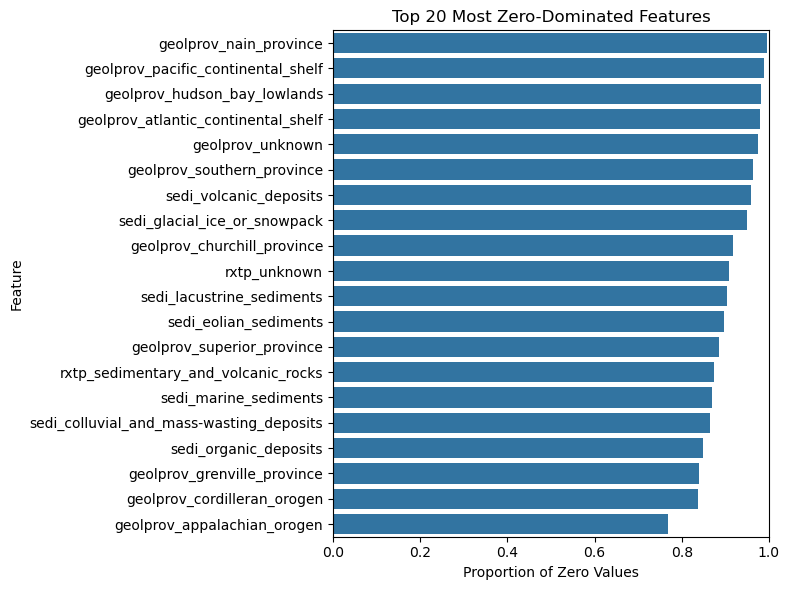

In [199]:
top_n = 20

zero_top = low_var.sort_values(
    by="zero_prop",
    ascending=False
).head(top_n).copy()

plt.figure(figsize=(8, 6))
sns.barplot(
    data=zero_top,
    x="zero_prop",
    y="feature"
)
plt.title(f"Top {top_n} Most Zero-Dominated Features")
plt.xlabel("Proportion of Zero Values")
plt.ylabel("Feature")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

#### Correlation diagnostics

This section flags feature pairs with absolute correlation above 0.8 for redundancy review.

Highly correlated features are not removed automatically at this stage.

In [177]:
# Correlation matrix
corr_matrix = X.corr()

# Keep only upper triangle to avoid duplicate pairs
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Convert to long format and filter by threshold
CORR_THRESHOLD = 0.8

high_corr_pairs = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "corr"})
)

high_corr_pairs["abs_corr"] = high_corr_pairs["corr"].abs()

high_corr_pairs = (
    high_corr_pairs.loc[high_corr_pairs["abs_corr"] > CORR_THRESHOLD]
    .sort_values(by="abs_corr", ascending=False)
    .reset_index(drop=True)
)

high_corr_pairs.head(20)

,feature_1,feature_2,corr,abs_corr
0,demogr_pop_2016,demogr_num_occ_dwellings,0.981500,0.981500
1,demogr_num_total_dwellings,demogr_num_occ_dwellings,0.978219,0.978219
2,socioeco_frac_overcrowded,socioeco_frac_unsuitable_housing,0.969734,0.969734
3,demogr_pop_2016,demogr_num_total_dwellings,0.950072,0.950072
4,hous_frac_type_single_detached,hous_frac_type_other_attached,-0.922378,0.922378
5,hous_frac_age_pre_1980,hous_frac_age_post_2001,-0.862991,0.862991
6,demogr_frac_tenure_band,socioeco_frac_overcrowded,0.858228,0.858228
7,hous_frac_major_repair,demogr_frac_tenure_band,0.856863,0.856863
8,rxtp_metamorphic_rocks,geolprov_grenville_province,0.846090,0.846090
9,demogr_frac_tenure_owned,demogr_frac_tenure_rented,-0.830214,0.830214


Which to drop/keep?

1. `demogr_pop_2016`, `demogr_num_occ_dwellings`, `demogr_num_total_dwellings`: keep `demogr_num_occ_dwellings`.

2. `socioeco_frac_overcrowded`, `socioeco_frac_unsuitable_housing`, `demogr_frac_tenure_band`, `demogr_frac_tenure_owned`: 

    delete `socioeco_frac_unsuitable_housing`.

3. `hous_frac_type_single_detached`, `hous_frac_type_other_attached`: delete `hous_frac_type_other_attached`.

4. `hous_frac_age_pre_1980`, `hous_frac_age_post_2001`: delete `hous_frac_age_post_2001`.

5. `rxtp_metamorphic_rocks`, `geolprov_grenville_province`: delete `geolprov_grenville_province`.

6. `demogr_frac_tenure_owned`, `demogr_frac_tenure_rented`: delete `demogr_frac_tenure_rented`.

7. `socioeco_median_income`, `socioeco_frac_high_income`: delete `socioeco_frac_high_income`.

8. `socioeco_frac_govt_transfers`,	`socioeco_frac_nonlaborer`: delete `socioeco_frac_nonlaborer`


In [178]:
# Identify high-correlated features (determine whether to drop or not based on model nature)
high_corr_drop_optional = [
    "demogr_pop_2016", "demogr_num_total_dwellings",
    "socioeco_frac_unsuitable_housing",
    "socioeco_frac_high_income", 
    "socioeco_frac_nonlaborer",
    "geolprov_grenville_province"
    #"hous_frac_type_other_attached",            ### Remove this feature later in compositional_drop
    #"hous_frac_age_post_2001",                  ### Remove this feature later in compositional_drop
    #"demogr_frac_tenure_rented",                ### Remove this feature later in compositional_drop
    #"rxtp_sedimentary_and_volcanic_rocks",      ### Remove this feature later in compositional_drop
]

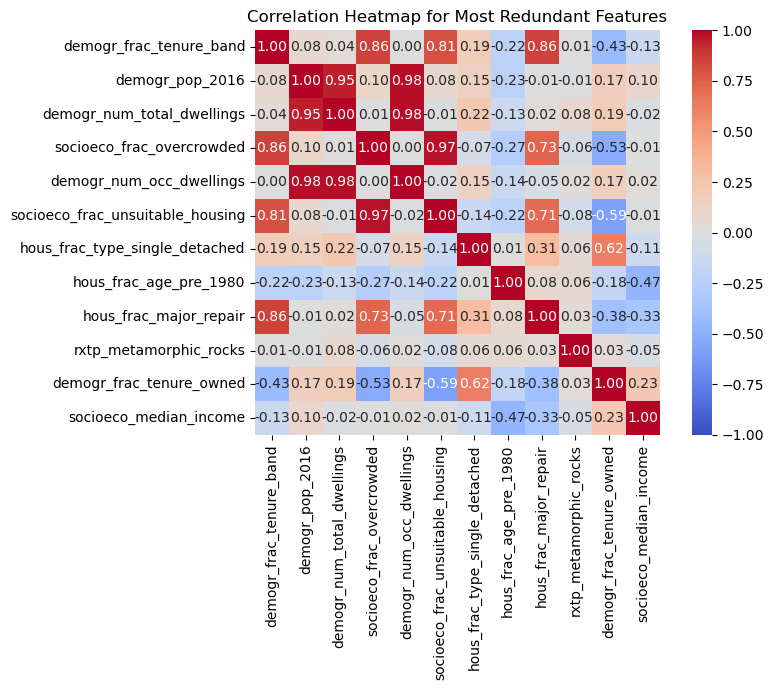

In [196]:
corr_feature_counts = pd.concat(
    [high_corr_pairs["feature_1"], high_corr_pairs["feature_2"]]
).value_counts()

top_corr_features = corr_feature_counts.head(12).index.tolist()

corr_subset_small = X[top_corr_features].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_subset_small,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    square=True
)
plt.title("Correlation Heatmap for Most Redundant Features")
plt.tight_layout()
plt.show()

#### Mutual information

In [ ]:
# Household-level target
y = df["radon_danger_conc"].copy()

# Use numeric features only for MI
X_mi = X.select_dtypes(include=[np.number]).copy()

# Compute mutual information
mi_scores = mutual_info_classif(
    X_mi,
    y,
    random_state=12345
)

mi_df = pd.DataFrame({
    "feature": X_mi.columns,
    "mi_score": mi_scores
})

mi_df = mi_df.sort_values(
    by="mi_score",
    ascending=False
).reset_index(drop=True)

print(f"Number of features evaluated by MI: {len(mi_df)}")
mi_df.head(110)

Number of features evaluated by MI: 65


,feature,mi_score
0,hous_frac_type_single_detached,0.049867
1,hous_frac_major_repair,0.049510
2,demogr_pop_2016,0.049222
3,socioeco_median_income,0.049151
4,socioeco_frac_bachelor_plus,0.048335
5,longitude,0.047579
6,hous_frac_type_movable,0.047500
7,hous_median_value,0.047390
8,demogr_num_total_dwellings,0.046675
9,hous_frac_age_pre_1980,0.046639


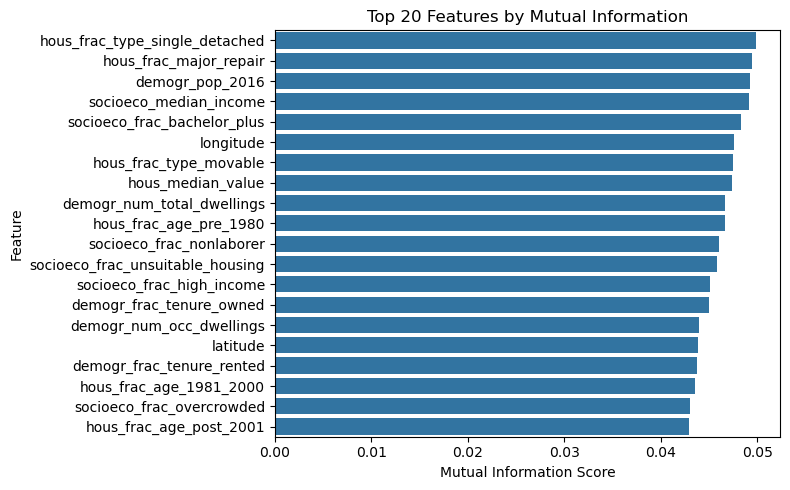

In [192]:
# Top MI bar plot
top_n = 20

mi_top = mi_df.head(top_n).copy()

plt.figure(figsize=(8, 5))
sns.barplot(
    data=mi_top,
    x="mi_score",
    y="feature"
)
plt.title(f"Top {top_n} Features by Mutual Information")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [180]:
mi_df.tail(20)

,feature,mi_score
45,sedi_volcanic_deposits,0.005480
46,geolprov_grenville_province,0.005229
47,geolprov_interior_platform,0.005091
48,demogr_avg_household_size,0.004774
49,geolprov_appalachian_orogen,0.004598
50,rxtp_unknown,0.004152
51,geolprov_superior_province,0.003584
52,geolprov_nain_province,0.003446
53,sedi_eolian_sediments,0.002769
54,hous_avg_rooms,0.001300


In [181]:
# Drop features with very low MI (determine whether to drop or not based on model nature)
low_MI = [
    "hous_avg_rooms",
    #"geolprov_unknown",                ### Remove this feature in compositional_drop
    #"geolprov_hudson_bay_lowlands"     ### Remove this feature in compositional_drop
]


#### Compositional feature groups

Five feature groups have components which sum up to 1. One column is removed according to high correlation and MI results.

In [182]:
# Choose one column in feature groups whose components sum to 1 according to high correlation and MI results
compositional_drop = [
    "hous_frac_type_other_attached",
    "hous_frac_age_post_2001", 
    "demogr_frac_tenure_rented", 
    "rxtp_sedimentary_and_volcanic_rocks",
    "geolprov_unknown",
    "geolprov_hudson_bay_lowlands"
]


In [183]:
X.columns

Index(['longitude', 'latitude', 'hous_frac_type_single_detached',
       'hous_frac_type_highrise', 'hous_frac_type_other_attached',
       'hous_frac_type_movable', 'hous_avg_rooms', 'hous_frac_major_repair',
       'hous_frac_age_pre_1980', 'hous_frac_age_1981_2000',
       'hous_frac_age_post_2001', 'hous_median_value', 'demogr_pop_2016',
       'demogr_num_total_dwellings', 'demogr_num_occ_dwellings',
       'demogr_median_age', 'demogr_avg_household_size',
       'demogr_frac_tenure_owned', 'demogr_frac_tenure_rented',
       'demogr_frac_tenure_band', 'socioeco_frac_low_income',
       'socioeco_median_income', 'socioeco_frac_high_income',
       'socioeco_frac_govt_transfers', 'socioeco_frac_unemployment_rate',
       'socioeco_frac_nonlaborer', 'socioeco_frac_bachelor_plus',
       'socioeco_frac_overcrowded', 'socioeco_frac_unsuitable_housing',
       'socioeco_frac_housing_burden', 'rxtp_intrusive_rocks',
       'rxtp_metamorphic_rocks', 'rxtp_sedimentary_and_volcanic_rocks',

In [184]:
# Drop compositional columns
drop_now_cols = sorted(set(list(compositional_drop)))
X = X.drop(columns=drop_now_cols)

### Key takeaways

In [185]:
FEATURE_KEEP = X.columns
FEATURE_KEEP

Index(['longitude', 'latitude', 'hous_frac_type_single_detached',
       'hous_frac_type_highrise', 'hous_frac_type_movable', 'hous_avg_rooms',
       'hous_frac_major_repair', 'hous_frac_age_pre_1980',
       'hous_frac_age_1981_2000', 'hous_median_value', 'demogr_pop_2016',
       'demogr_num_total_dwellings', 'demogr_num_occ_dwellings',
       'demogr_median_age', 'demogr_avg_household_size',
       'demogr_frac_tenure_owned', 'demogr_frac_tenure_band',
       'socioeco_frac_low_income', 'socioeco_median_income',
       'socioeco_frac_high_income', 'socioeco_frac_govt_transfers',
       'socioeco_frac_unemployment_rate', 'socioeco_frac_nonlaborer',
       'socioeco_frac_bachelor_plus', 'socioeco_frac_overcrowded',
       'socioeco_frac_unsuitable_housing', 'socioeco_frac_housing_burden',
       'rxtp_intrusive_rocks', 'rxtp_metamorphic_rocks',
       'rxtp_sedimentary_rocks', 'rxtp_unknown', 'rxtp_volcanic_rocks',
       'geolprov_appalachian_orogen', 'geolprov_atlantic_continental_

In [186]:
FEATURE_DROP = sorted(set(FEATURE_DROP + drop_now_cols))
FEATURE_DROP

['FSA',
 'concentration',
 'cv_fold',
 'demogr_frac_tenure_rented',
 'geolprov_arctic_continental_shelf',
 'geolprov_arctic_platform',
 'geolprov_bear_province',
 'geolprov_hudson_bay_lowlands',
 'geolprov_innuitian_orogen',
 'geolprov_oceanic_crust',
 'geolprov_slave_province',
 'geolprov_unknown',
 'geometry',
 'hous_frac_age_post_2001',
 'hous_frac_type_other_attached',
 'is_test',
 'n_days',
 'provinceterritory',
 'radon_danger_conc',
 'rxtp_sedimentary_and_volcanic_rocks',
 'sedi_weathered_bedrock_or_regolith',
 'spatial_cluster']

Optional features to delete, based on different models:

In [187]:
# High correlation features
high_corr_drop_optional = [
    "demogr_pop_2016", "demogr_num_total_dwellings",
    "socioeco_frac_unsuitable_housing",
    "socioeco_frac_high_income", 
    "socioeco_frac_nonlaborer",
    "geolprov_grenville_province"
]

In [188]:
# Low MI feature
low_MI = [
    "hous_avg_rooms"
]